# Multilevel Monte Carlo (MLMC) Path Simulation

## Problem

Price a European call option under GBM,

```
dS = r S dt + sigma S dW
```

by Monte Carlo simulation of an Euler-Maruyama discretization of `S`, and estimate
`E[max(S_T - K, 0)]` (discounted) for the same target root-mean-square accuracy using two
approaches: standard (single-level) Monte Carlo at a fixed fine time step, and Multilevel Monte
Carlo (MLMC), which spreads the simulation budget across a hierarchy of time-step resolutions to
reach the same accuracy at much lower computational cost.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

S0 = 100.0
K = 100.0
r = 0.05
sigma = 0.20
T = 1.0


def bs_call_price(S0, K, r, sigma, T):
    d1 = (np.log(S0 / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return S0 * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)


true_price = bs_call_price(S0, K, r, sigma, T)
print(f"Closed-form Black-Scholes call price: {true_price:.6f}")

Closed-form Black-Scholes call price: 10.450584


## Method

Following Giles (2008), define a hierarchy of levels `l = 0, 1, ..., L` with time steps
`dt_l = dt_0 * M^{-l}` (here `M = 4`). The quantity of interest is the discounted payoff
`P = e^{-rT} max(S_T - K, 0)`, and its expectation is decomposed as a telescoping sum:

```
E[P_L] = E[P_0] + sum_{l=1}^{L} E[P_l - P_{l-1}]
```

where `P_l` is the payoff computed from an Euler-Maruyama path with step `dt_l`. Each term on the
right is estimated by an independent Monte Carlo sample:

- **Level 0**: `N_0` independent paths at the coarsest step `dt_0`, estimating `E[P_0]` directly.
- **Level l > 0**: `N_l` pairs of paths that share the *same* Brownian path — a fine path at step
  `dt_l` and a coarse path at step `dt_{l-1} = M * dt_l`, built by summing every `M` consecutive
  fine Brownian increments to get each coarse increment. Using the same driving noise for both
  resolutions makes `P_l` and `P_{l-1}` strongly correlated, so `Var[P_l - P_{l-1}]` is much
  smaller than `Var[P_l]` alone — this coupling is what makes MLMC work.

The overall MLMC estimator is unbiased for `E[P_L]` with variance
`Var[Y_MLMC] = sum_l Var[P_l - P_{l-1}] / N_l`, and the number of samples `N_l` at each level is
chosen (per Giles' Theorem 2.1) to minimize total computational cost for a target variance
`epsilon^2`:

```
N_l = ceil( 2 epsilon^{-2} sqrt(V_l / C_l) * sum_l sqrt(V_l C_l) )
```

where `V_l = Var[P_l - P_{l-1}]` and `C_l` is the cost of one sample at level `l` (proportional to
`1/dt_l`, since the number of Euler steps scales that way).

In [2]:
def simulate_level(n_paths, dt_fine, M, rng, level0=False):
    """Simulate n_paths of the fine (and, unless level0, coupled coarse) GBM path via
    Euler-Maruyama, return discounted payoff differences P_fine - P_coarse (or just P_fine
    if level0)."""
    n_fine_steps = int(round(T / dt_fine))
    # Brownian increments for the fine path
    dW_fine = rng.standard_normal((n_paths, n_fine_steps)) * np.sqrt(dt_fine)

    S_fine = np.full(n_paths, S0)
    for i in range(n_fine_steps):
        S_fine = S_fine + r * S_fine * dt_fine + sigma * S_fine * dW_fine[:, i]
    payoff_fine = np.exp(-r * T) * np.maximum(S_fine - K, 0.0)

    if level0:
        return payoff_fine, None

    # Coarse path shares the same driving noise: sum every M fine increments
    n_coarse_steps = n_fine_steps // M
    dW_coarse = dW_fine.reshape(n_paths, n_coarse_steps, M).sum(axis=2)
    dt_coarse = dt_fine * M

    S_coarse = np.full(n_paths, S0)
    for i in range(n_coarse_steps):
        S_coarse = S_coarse + r * S_coarse * dt_coarse + sigma * S_coarse * dW_coarse[:, i]
    payoff_coarse = np.exp(-r * T) * np.maximum(S_coarse - K, 0.0)

    return payoff_fine, payoff_coarse


M = 4
dt0 = T / 4          # level-0 (coarsest) step
L = 5                # levels 0..L
n_pilot = 20_000      # pilot sample size to estimate V_l, C_l per level

rng = np.random.default_rng(42)

levels = list(range(L + 1))
V_l = []
C_l = []
for l in levels:
    dt_fine = dt0 / (M ** l)
    if l == 0:
        p_fine, _ = simulate_level(n_pilot, dt_fine, M, rng, level0=True)
        diff = p_fine
    else:
        p_fine, p_coarse = simulate_level(n_pilot, dt_fine, M, rng, level0=False)
        diff = p_fine - p_coarse
    V_l.append(diff.var())
    C_l.append(1.0 / dt_fine)   # cost per path proportional to number of fine steps

V_l = np.array(V_l)
C_l = np.array(C_l)
for l in levels:
    print(f"level {l}: dt={dt0 / (M**l):.6f}  V_l={V_l[l]:.6e}  C_l={C_l[l]:.1f}")

level 0: dt=0.250000  V_l=2.041216e+02  C_l=4.0
level 1: dt=0.062500  V_l=1.086927e+00  C_l=16.0
level 2: dt=0.015625  V_l=2.849967e-01  C_l=64.0
level 3: dt=0.003906  V_l=6.871962e-02  C_l=256.0
level 4: dt=0.000977  V_l=1.732162e-02  C_l=1024.0
level 5: dt=0.000244  V_l=4.298075e-03  C_l=4096.0


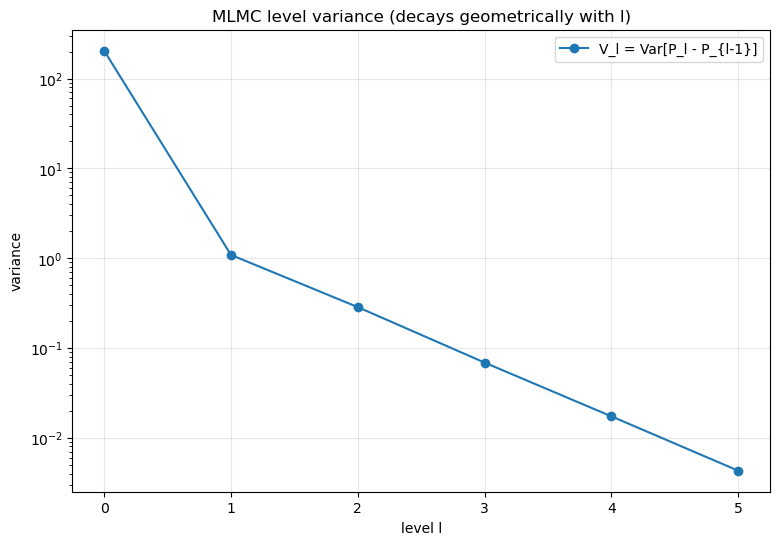

In [3]:
plt.figure(figsize=(9, 6))
plt.semilogy(levels, V_l, "o-", label="V_l = Var[P_l - P_{l-1}]")
plt.xlabel("level l")
plt.ylabel("variance")
plt.title("MLMC level variance (decays geometrically with l)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.savefig("mlmc_level_variance.png", dpi=120, bbox_inches="tight")
plt.show()

## Optimal sample allocation and cost comparison

For a target RMSE `epsilon`, the optimal `N_l` from the pilot variance/cost estimates above gives
the total MLMC cost `sum_l N_l C_l`. This is compared against the cost of reaching the *same*
`epsilon` with standard (single-level) Monte Carlo at the finest level's step size `dt_L`, whose
required sample count is `N_std = Var[P_L] / epsilon^2` (using the total variance of the finest
level's payoff, not just the level correction).

In [4]:
def mlmc_price(epsilon, V_l, C_l, dt0, M, rng):
    total_sqrt_VC = np.sum(np.sqrt(V_l * C_l))
    N_l = np.ceil(2 * epsilon**-2 * np.sqrt(V_l / C_l) * total_sqrt_VC).astype(int)
    N_l = np.maximum(N_l, 1)

    estimate = 0.0
    total_cost = 0.0
    for l, n in zip(levels, N_l):
        dt_fine = dt0 / (M ** l)
        if l == 0:
            p_fine, _ = simulate_level(n, dt_fine, M, rng, level0=True)
            diff = p_fine
        else:
            p_fine, p_coarse = simulate_level(n, dt_fine, M, rng, level0=False)
            diff = p_fine - p_coarse
        estimate += diff.mean()
        total_cost += n * C_l[l]

    return estimate, total_cost, N_l


target_epsilons = np.array([0.05, 0.02, 0.01, 0.005])
mlmc_costs = []
std_costs = []

# Variance of the finest level's raw payoff (needed for the standard-MC cost formula)
dt_finest = dt0 / (M ** L)
p_finest, _ = simulate_level(n_pilot, dt_finest, M, rng, level0=True)
var_finest = p_finest.var()

for eps in target_epsilons:
    est, cost, N_l = mlmc_price(eps, V_l, C_l, dt0, M, rng)
    mlmc_costs.append(cost)
    std_cost = var_finest / eps**2 * C_l[-1]
    std_costs.append(std_cost)
    print(f"epsilon={eps:.3f}  MLMC estimate={est:.4f}  MLMC cost={cost:.3e}  standard-MC cost={std_cost:.3e}  speedup={std_cost/cost:.1f}x")

mlmc_costs = np.array(mlmc_costs)
std_costs = np.array(std_costs)

epsilon=0.050  MLMC estimate=10.4642  MLMC cost=1.972e+06  standard-MC cost=3.560e+08  speedup=180.5x


epsilon=0.020  MLMC estimate=10.4367  MLMC cost=1.231e+07  standard-MC cost=2.225e+09  speedup=180.7x


epsilon=0.010  MLMC estimate=10.4413  MLMC cost=4.924e+07  standard-MC cost=8.900e+09  speedup=180.7x


epsilon=0.005  MLMC estimate=10.4495  MLMC cost=1.970e+08  standard-MC cost=3.560e+10  speedup=180.8x


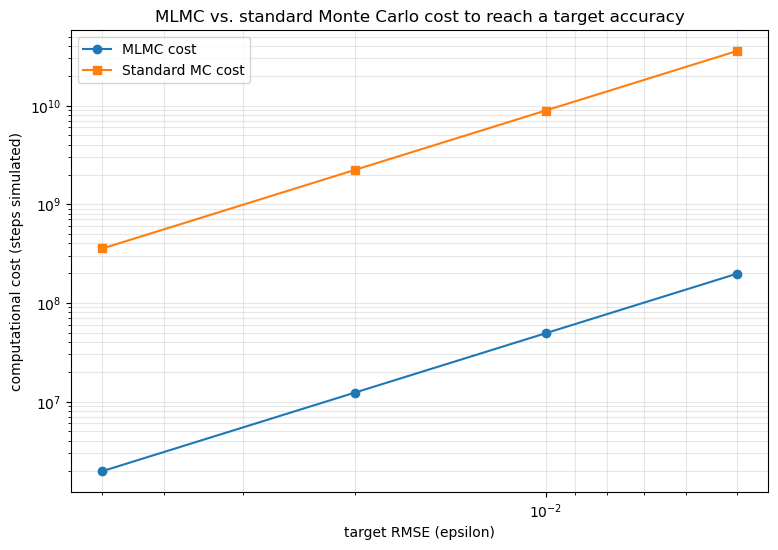

In [5]:
plt.figure(figsize=(9, 6))
plt.loglog(target_epsilons, mlmc_costs, "o-", label="MLMC cost")
plt.loglog(target_epsilons, std_costs, "s-", label="Standard MC cost")
plt.gca().invert_xaxis()
plt.xlabel("target RMSE (epsilon)")
plt.ylabel("computational cost (steps simulated)")
plt.title("MLMC vs. standard Monte Carlo cost to reach a target accuracy")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.savefig("mlmc_vs_standard_cost.png", dpi=120, bbox_inches="tight")
plt.show()